In [15]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [16]:
df=pd.read_csv(r'D:\code\ml or python\churn_prediction_project\data\train_data.csv')

In [17]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [19]:
df.isnull().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [20]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [21]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
print(df['TotalCharges'].isnull().sum())

11


In [22]:
df.dropna(subset=['TotalCharges'],inplace=True)
print("New dataset shape",df.shape)
print("Remaining nulls", df['TotalCharges'].isnull().sum())

New dataset shape (7032, 21)
Remaining nulls 0


In [23]:
for col in df.select_dtypes(include=['object']).columns:
    print(f"---Unique values in '{col}'---")
    print(df[col].unique())
    print("\n")

---Unique values in 'customerID'---
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']


---Unique values in 'gender'---
['Female' 'Male']


---Unique values in 'Partner'---
['Yes' 'No']


---Unique values in 'Dependents'---
['No' 'Yes']


---Unique values in 'PhoneService'---
['No' 'Yes']


---Unique values in 'MultipleLines'---
['No phone service' 'No' 'Yes']


---Unique values in 'InternetService'---
['DSL' 'Fiber optic' 'No']


---Unique values in 'OnlineSecurity'---
['No' 'Yes' 'No internet service']


---Unique values in 'OnlineBackup'---
['Yes' 'No' 'No internet service']


---Unique values in 'DeviceProtection'---
['No' 'Yes' 'No internet service']


---Unique values in 'TechSupport'---
['No' 'Yes' 'No internet service']


---Unique values in 'StreamingTV'---
['No' 'Yes' 'No internet service']


---Unique values in 'StreamingMovies'---
['No' 'Yes' 'No internet service']


---Unique values in 'Contract'---
['Month-to-month' 'One year' 'Two year'

In [24]:
import seaborn as sns 

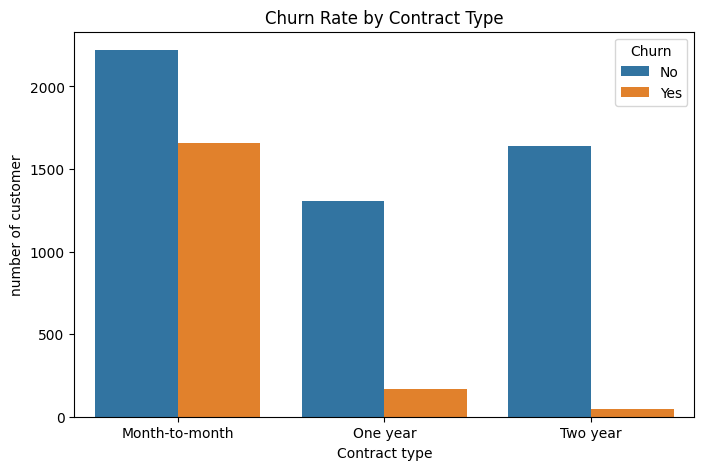

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='Contract',hue='Churn')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract type')
plt.ylabel('number of customer')
plt.show()

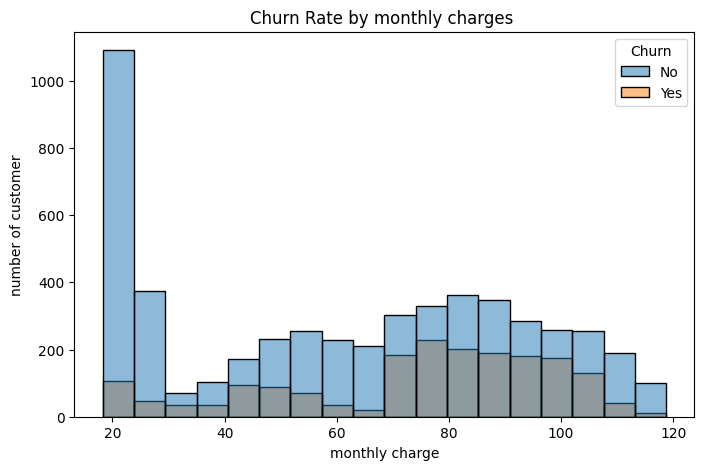

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x='MonthlyCharges',hue='Churn',fill=True)
plt.title('Churn Rate by monthly charges ')
plt.xlabel('monthly charge')
plt.ylabel('number of customer')
plt.show()

ONE HOT ENCODING

In [27]:
if 'customerID' in df.columns:
    df=df.drop(columns=['customerID'])

df_encoded=pd.get_dummies(df,drop_first=True)

print(df_encoded.head())
print("\n New shape of dataset:",df_encoded.shape)

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  StreamingTV_Yes  \
0                            True              False  ...            False   
1                           False              False  ...            False   
2                         

SPLITING DATA

In [30]:
X= df_encoded.drop(columns=['Churn_Yes'])
y=df_encoded['Churn_Yes']

print("Fetures shape (X)",X.shape)
print("Target shape(y)",y.shape)

Fetures shape (X) (7032, 30)
Target shape(y) (7032,)


In [29]:
print(df_encoded.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes'],
      dtype='object')


TRAIN TEST SPLIT 

In [31]:
from sklearn.model_selection import train_test_split

X_train ,X_test, y_train , y_test= train_test_split(X,y,test_size=0.2 , random_state=42)
print("training samples:",X_train.shape)
print("testing samples:",X_test.shape)

training samples: (5625, 30)
testing samples: (1407, 30)


TRAINING MODEL

In [34]:
from sklearn.linear_model import LogisticRegression

model =LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)
print("Model training complete!")

Model training complete!


c:\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


PREDICTION

In [35]:
y_pred= model.predict(X_test)

from sklearn.metrics import accuracy_score
print("basic accuracy score:",accuracy_score(y_test,y_pred))

basic accuracy score: 0.7853589196872779


In [36]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.83      0.88      0.86      1033
        True       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



BALANCING THE MODEL

In [37]:
balanced_model = LogisticRegression(max_iter=1000,class_weight='balanced')

balanced_model.fit(X_train,y_train)

y_pred_balanced=balanced_model.predict(X_test)

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

       False       0.91      0.71      0.80      1033
        True       0.50      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



c:\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


CHECKING FOR RESULTS USING RANDOM FOREST

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model= RandomForestClassifier(n_estimators=100, class_weight='balanced',random_state=42)

rf_model.fit(X_train,y_train)
y_rf_pred=rf_model.predict(X_test)

print(classification_report(y_test,y_rf_pred))

              precision    recall  f1-score   support

       False       0.82      0.91      0.86      1033
        True       0.63      0.45      0.53       374

    accuracy                           0.78      1407
   macro avg       0.73      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



In [40]:
import pickle


with open('balanced_model.pkl', 'wb') as file:
    pickle.dump(balanced_model, file)

print("Model successfully saved as balanced_model.pkl!")

Model successfully saved as balanced_model.pkl!
